# Heart Disease Prediction using Machine Learning

**Course:** Introduction to Data Science Lab (CSE 4114)
**Dataset:** Heart Disease UCI
**Task:** Classification

This notebook implements the complete data science workflow: problem definition, data cleaning, exploratory analysis, feature engineering, model building, evaluation, and interpretation of results for predicting the presence of heart disease in a patient.

## 1. Problem Statement and Project Objectives

### Problem Statement
Cardiovascular disease is one of the leading causes of death worldwide. Early identification of patients at risk allows clinicians to intervene sooner and improve outcomes. This project uses the Heart Disease UCI dataset to build a machine learning model that predicts whether a patient is likely to have heart disease based on clinical and diagnostic attributes such as age, blood pressure, cholesterol level, and results of exercise tests.

### Objectives
1. Clean and preprocess the raw clinical dataset, resolving missing values, duplicate records, and outliers.
2. Perform exploratory data analysis to understand feature distributions and their relationship with heart disease.
3. Engineer new and transformed features that may improve predictive signal.
4. Select the most informative features for modeling.
5. Train and compare several classification algorithms.
6. Evaluate the models using appropriate metrics and select the best performing, most clinically useful model.
7. Summarize findings, limitations, and possible directions for future work.

## 2. Dataset Description and Source

The Heart Disease UCI dataset originates from the UCI Machine Learning Repository, based on data collected at the Cleveland Clinic Foundation (Detrano et al., 1989). The commonly used processed version contains 303 patient records and 14 attributes, and is widely used as a benchmark for binary classification of heart disease presence.

**Source:** UCI Machine Learning Repository, Heart Disease dataset, DOI 10.24432/C52P4X. A CSV mirror of the processed Cleveland subset was used for this project (302 unique records after removing one duplicate row).

### Attribute Information
| Column | Description |
|---|---|
| age | Age of the patient in years |
| sex | Sex (1 = male, 0 = female) |
| cp | Chest pain type (0 typical angina, 1 atypical angina, 2 non anginal pain, 3 asymptomatic) |
| trestbps | Resting blood pressure in mm Hg |
| chol | Serum cholesterol in mg/dl |
| fbs | Fasting blood sugar greater than 120 mg/dl (1 = true, 0 = false) |
| restecg | Resting electrocardiographic results (0 normal, 1 ST T wave abnormality, 2 left ventricular hypertrophy) |
| thalach | Maximum heart rate achieved during exercise test |
| exang | Exercise induced angina (1 = yes, 0 = no) |
| oldpeak | ST depression induced by exercise relative to rest |
| slope | Slope of the peak exercise ST segment (0 upsloping, 1 flat, 2 downsloping) |
| ca | Number of major vessels (0 to 3) colored by fluoroscopy |
| thal | Thalassemia test result (1 fixed defect, 2 normal, 3 reversible defect) |
| target | Presence of heart disease (1 = disease, 0 = no disease) |

## 3. Data Collection

The dataset was obtained as a single CSV file containing all 303 records and 14 attributes. No additional data collection was required since the dataset is already compiled and labeled. The file is loaded directly with pandas below.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)
RANDOM_STATE = 42

In [ ]:
df = pd.read_csv('data/heart.csv', encoding='utf-8-sig')
df.columns = [c.strip() for c in df.columns]
print('Rows and columns:', df.shape)
df.head()

Rows and columns: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 4. Data Cleaning and Preprocessing

### 4.1 Initial Inspection

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### 4.2 Handling Missing Values

`df.isnull().sum()` shows no explicit `NaN` values, but the attribute dictionary states that `ca` should only take values 0 to 3 and `thal` should only take values 1 to 3. Values of `ca = 4` and `thal = 0` found in the raw file are known encoding artifacts from data entry and are treated as missing. They are imputed using the mode of each column, which is an appropriate strategy for low cardinality categorical attributes.

In [ ]:
print('Explicit nulls per column:')
print(df.isnull().sum().sum())

print('\nInvalid ca codes (should be 0 to 3):', (df['ca'] == 4).sum())
print('Invalid thal codes (should be 1 to 3):', (df['thal'] == 0).sum())

df['ca'] = df['ca'].replace(4, np.nan)
df['thal'] = df['thal'].replace(0, np.nan)

ca_mode = df['ca'].mode()[0]
thal_mode = df['thal'].mode()[0]
df['ca'] = df['ca'].fillna(ca_mode).astype(int)
df['thal'] = df['thal'].fillna(thal_mode).astype(int)

print('\nca imputed with mode:', ca_mode)
print('thal imputed with mode:', thal_mode)
print('Remaining nulls:', df.isnull().sum().sum())

Explicit nulls per column:
0

Invalid ca codes (should be 0 to 3): 5
Invalid thal codes (should be 1 to 3): 2

ca imputed with mode: 0.0
thal imputed with mode: 2.0
Remaining nulls: 0


### 4.3 Removing Duplicates

In [ ]:
n_dup = df.duplicated().sum()
print('Duplicate rows found:', n_dup)
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after removing duplicates:', df.shape)

Duplicate rows found: 1
Shape after removing duplicates: (302, 14)


### 4.4 Handling Outliers

Outliers in the continuous clinical measurements are identified using the interquartile range (IQR) rule and capped at the lower and upper bounds rather than removed, since these values (for example unusually high cholesterol) can be genuine and clinically meaningful rather than data errors.

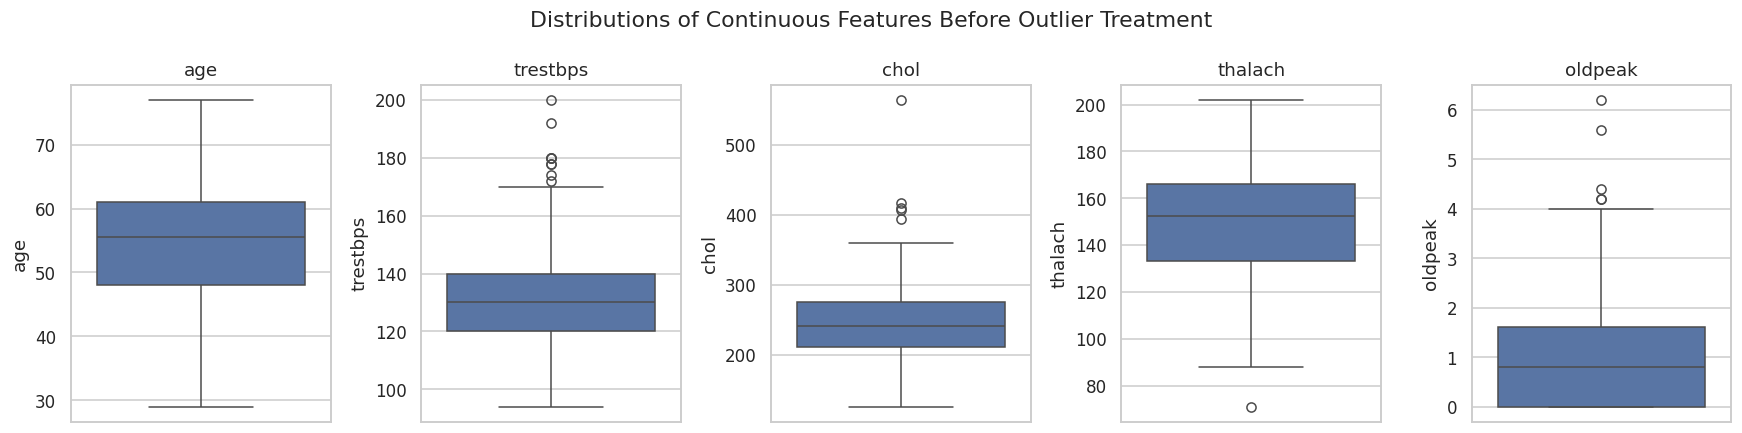

In [ ]:
cont_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(cont_cols), figsize=(16, 4))
for ax, col in zip(axes, cont_cols):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.suptitle('Distributions of Continuous Features Before Outlier Treatment')
plt.tight_layout()
plt.show()

In [ ]:
outlier_summary = []
for col in cont_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, n_out, round(lower, 2), round(upper, 2)])
    df[col] = df[col].clip(lower, upper)

pd.DataFrame(outlier_summary, columns=['Feature', 'Outliers Found', 'Lower Bound', 'Upper Bound'])

,Feature,Outliers Found,Lower Bound,Upper Bound
0,age,0,28.50,80.50
1,trestbps,9,90.00,170.00
2,chol,5,115.38,370.38
3,thalach,1,84.12,215.12
4,oldpeak,5,-2.40,4.00


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Variable Distribution

target
1    164
0    138
Name: count, dtype: int64

Class balance (percent):
target
1    54.3
0    45.7
Name: count, dtype: float64


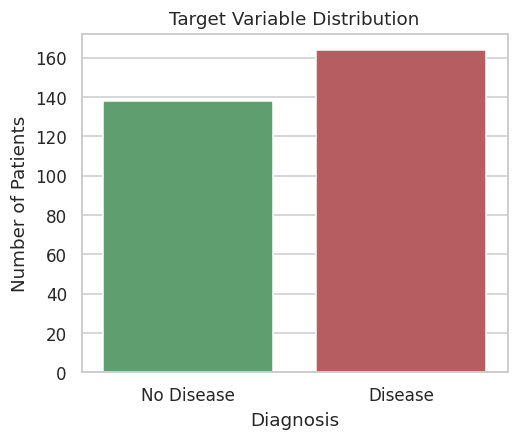

In [ ]:
target_counts = df['target'].value_counts()
print(target_counts)
print('\nClass balance (percent):')
print((target_counts / len(df) * 100).round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x='target', data=df, palette=['#55A868', '#C44E52'])
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.title('Target Variable Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
plt.show()

The dataset is reasonably balanced between the two classes, which means accuracy alone will still be an informative metric, though precision, recall, F1 score, and ROC AUC are also tracked to give a fuller picture.

### 5.2 Numerical Feature Distributions

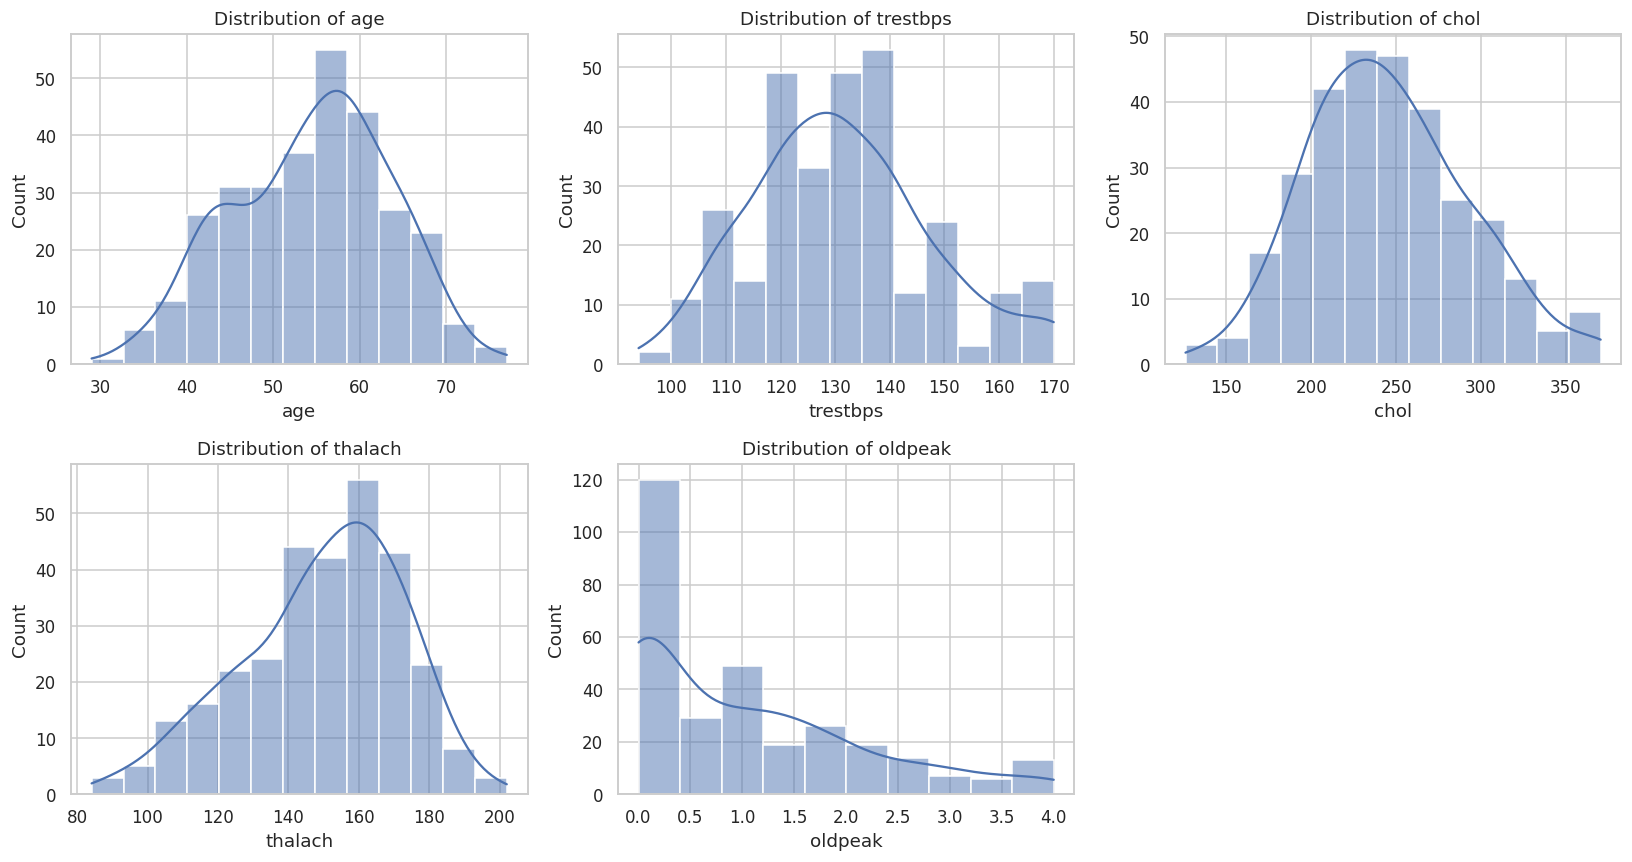

In [ ]:
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, num_features):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

### 5.3 Categorical Feature Analysis by Target

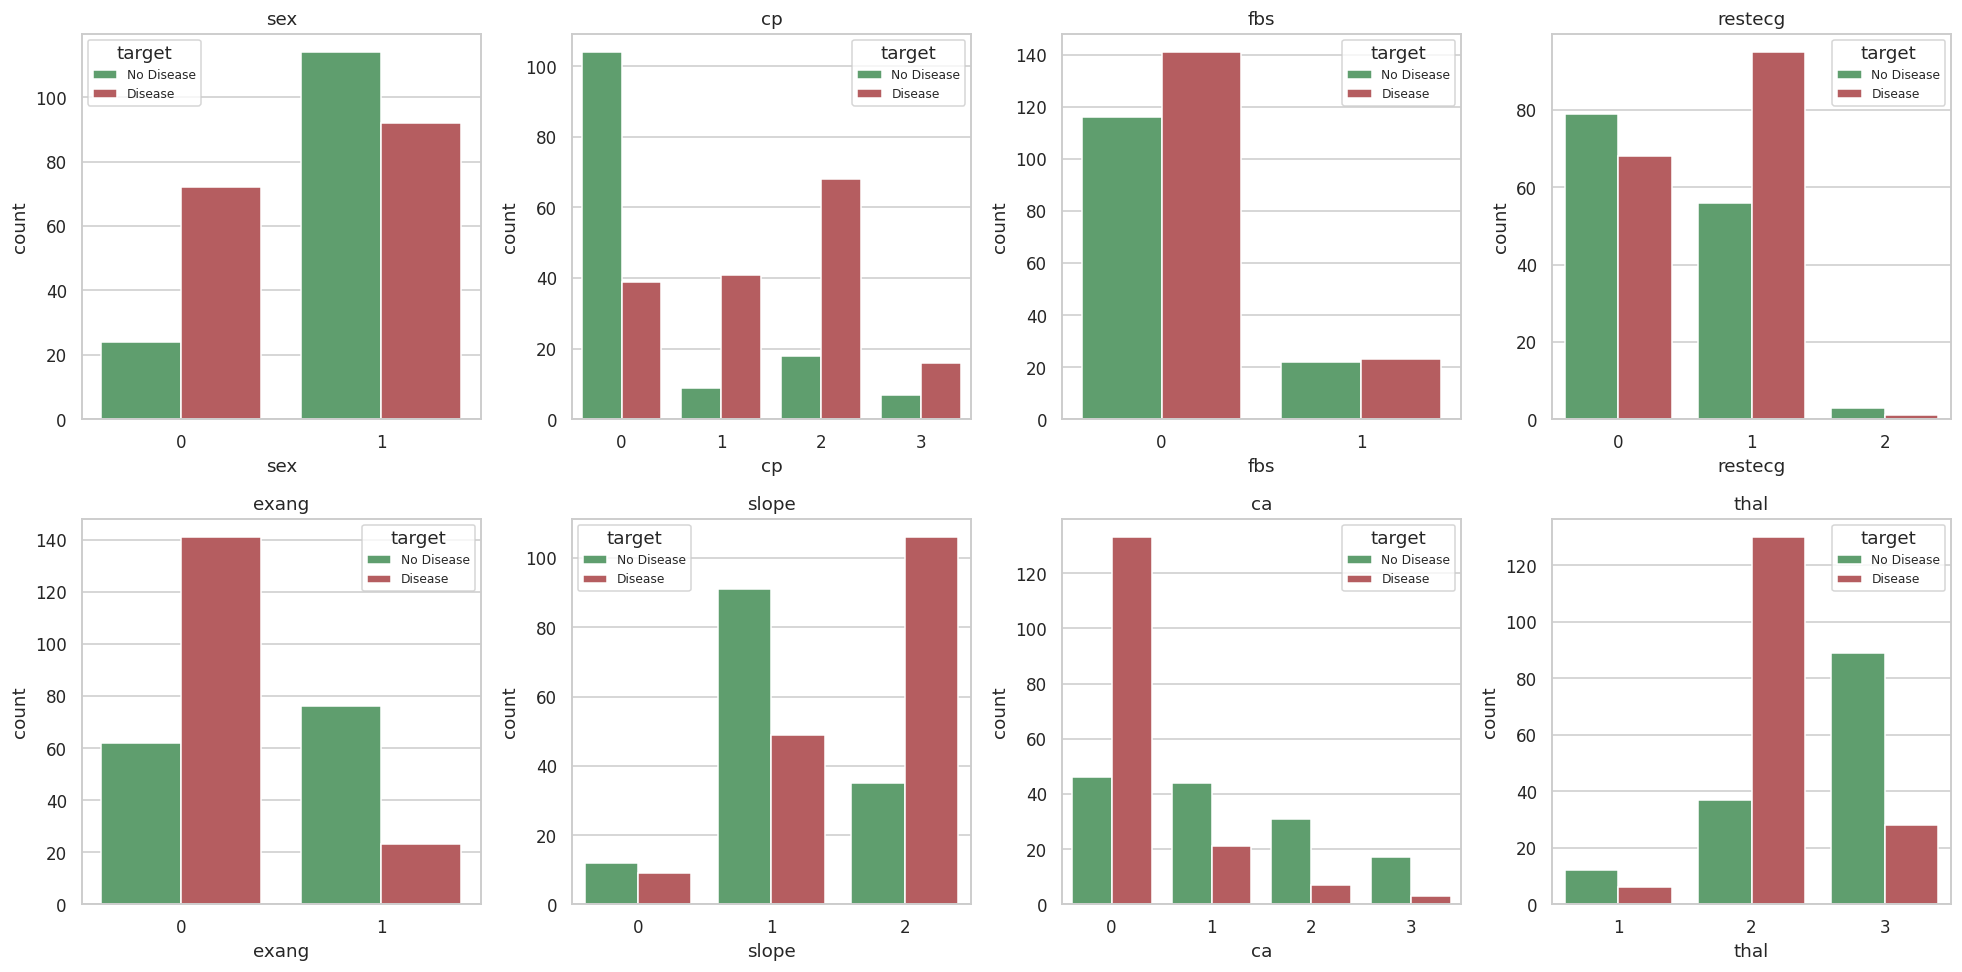

In [ ]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for ax, col in zip(axes, cat_features):
    sns.countplot(x=col, hue='target', data=df, ax=ax, palette=['#55A868', '#C44E52'])
    ax.set_title(col)
    ax.legend(title='target', labels=['No Disease', 'Disease'], fontsize=8)
plt.tight_layout()
plt.show()

### 5.4 Correlation Analysis

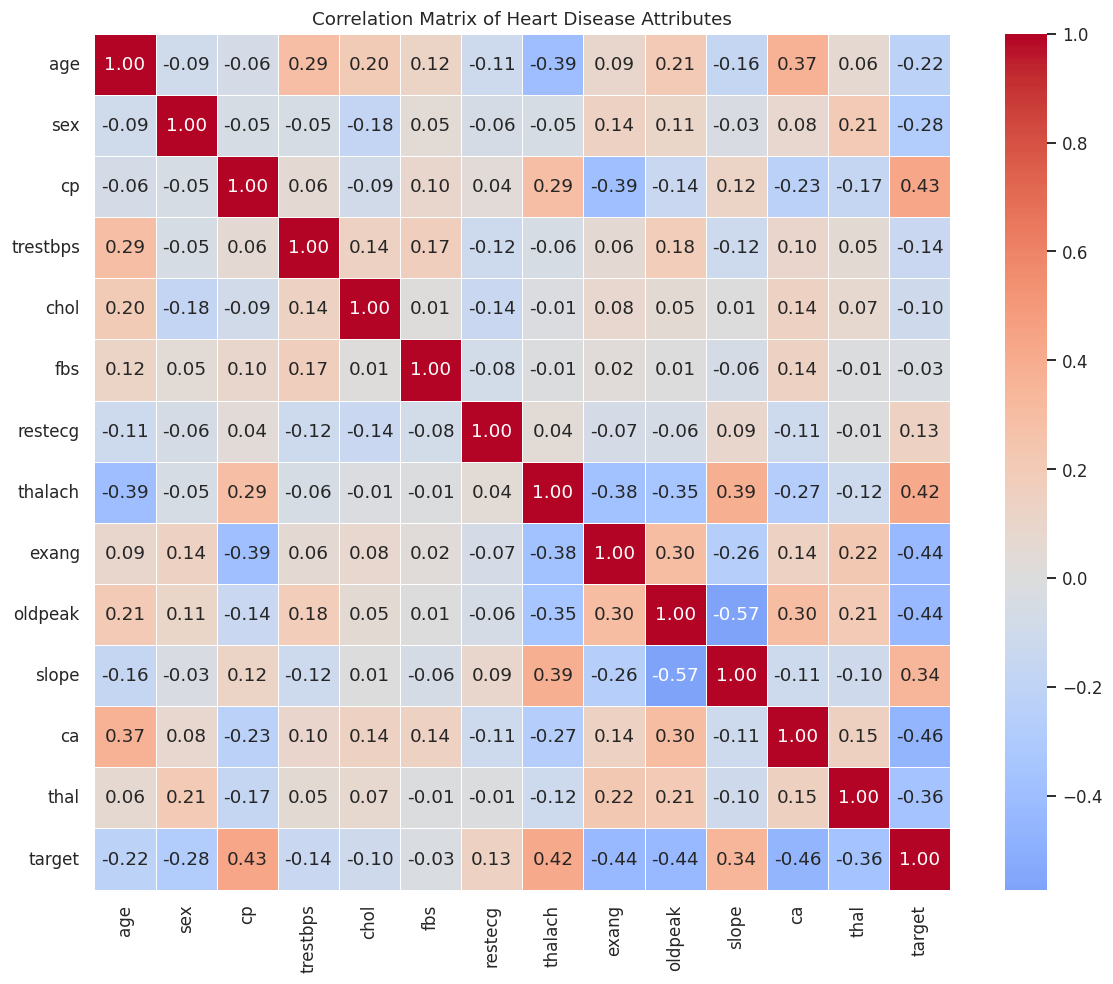

In [ ]:
plt.figure(figsize=(11, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.4)
plt.title('Correlation Matrix of Heart Disease Attributes')
plt.tight_layout()
plt.show()

In [ ]:
print('Correlation of each attribute with target, sorted by strength:')
corr['target'].drop('target').sort_values(key=abs, ascending=False)

Correlation of each attribute with target, sorted by strength:


ca         -0.463886
exang      -0.435601
oldpeak    -0.435099
cp          0.432080
thalach     0.420408
thal       -0.362313
slope       0.343940
sex        -0.283609
age        -0.221476
trestbps   -0.140083
restecg     0.134874
chol       -0.099932
fbs        -0.026826
Name: target, dtype: float64

### 5.5 Bivariate Analysis

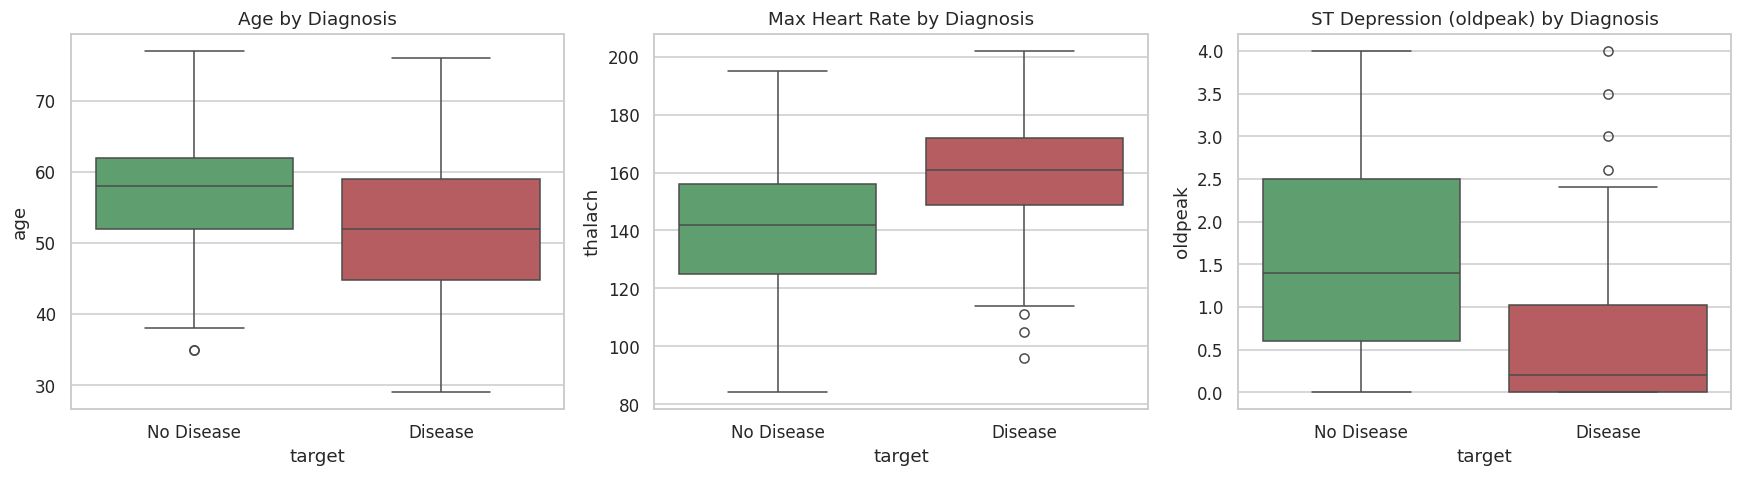

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(x='target', y='age', data=df, ax=axes[0], palette=['#55A868', '#C44E52'])
axes[0].set_xticklabels(['No Disease', 'Disease'])
axes[0].set_title('Age by Diagnosis')

sns.boxplot(x='target', y='thalach', data=df, ax=axes[1], palette=['#55A868', '#C44E52'])
axes[1].set_xticklabels(['No Disease', 'Disease'])
axes[1].set_title('Max Heart Rate by Diagnosis')

sns.boxplot(x='target', y='oldpeak', data=df, ax=axes[2], palette=['#55A868', '#C44E52'])
axes[2].set_xticklabels(['No Disease', 'Disease'])
axes[2].set_title('ST Depression (oldpeak) by Diagnosis')
plt.tight_layout()
plt.show()

**Observations from EDA**

* Chest pain type, exercise induced angina, ST segment slope, the number of major vessels, and the thalassemia result show the clearest separation between patients with and without heart disease.
* Patients with heart disease tend to reach a higher maximum heart rate and show lower ST depression during exercise in this dataset, which is consistent with known clinical patterns for this cohort.
* No single feature perfectly separates the classes, which motivates the use of multivariate machine learning models rather than a simple rule based on one attribute.

## 6. Feature Engineering

### 6.1 Feature Creation

Three new features are created from domain knowledge:
* `hr_reserve`, the difference between the age predicted maximum heart rate (220 minus age) and the observed maximum heart rate achieved (`thalach`). A larger reserve can indicate reduced cardiovascular fitness.
* `age_group`, a categorical bucket (young, middle, senior) capturing nonlinear age effects.
* `chol_level`, a categorical bucket (normal, borderline, high) based on standard clinical cholesterol thresholds.

In [ ]:
df['hr_reserve'] = (220 - df['age']) - df['thalach']
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 55, 100], labels=['young', 'middle', 'senior'])
df['chol_level'] = pd.cut(df['chol'], bins=[0, 200, 240, 1000], labels=['normal', 'borderline', 'high'])

df[['age', 'thalach', 'hr_reserve', 'age_group', 'chol', 'chol_level']].head()

,age,thalach,hr_reserve,age_group,chol,chol_level
0,63,150.0,7.0,senior,233.0,borderline
1,37,187.0,-4.0,young,250.0,high
2,41,172.0,7.0,middle,204.0,borderline
3,56,178.0,-14.0,senior,236.0,borderline
4,57,163.0,0.0,senior,354.0,high


### 6.2 Feature Transformation

`oldpeak` is right skewed since most patients show little to no ST depression while a smaller group shows large values. A `log1p` transform reduces this skew and helps distance based and linear models treat the feature more evenly.

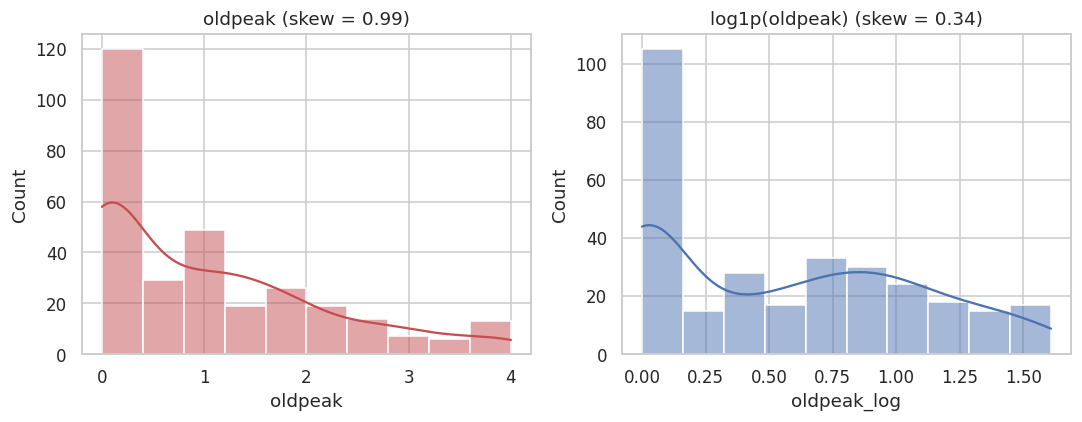

In [ ]:
skew_before = skew(df['oldpeak'])
df['oldpeak_log'] = np.log1p(df['oldpeak'])
skew_after = skew(df['oldpeak_log'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['oldpeak'], kde=True, ax=axes[0], color='#C44E52')
axes[0].set_title(f'oldpeak (skew = {skew_before:.2f})')
sns.histplot(df['oldpeak_log'], kde=True, ax=axes[1], color='#4C72B0')
axes[1].set_title(f'log1p(oldpeak) (skew = {skew_after:.2f})')
plt.tight_layout()
plt.show()

### 6.3 Encoding Categorical Variables

`sex`, `fbs`, and `exang` are already binary, so no further encoding is needed. The remaining nominal attributes (`cp`, `restecg`, `slope`, `thal`, plus the engineered `age_group` and `chol_level`) are one hot encoded so that the model does not assume a false numeric ordering between their categories. `ca` is left as an ordinal count since it genuinely represents a count of vessels.

In [ ]:
nominal_cols = ['cp', 'restecg', 'slope', 'thal', 'age_group', 'chol_level']
df_enc = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
df_enc = df_enc.drop(columns=['oldpeak'])  # replaced by oldpeak_log

print('Shape after encoding:', df_enc.shape)
df_enc.head()

Shape after encoding: (302, 24)


,age,sex,trestbps,chol,fbs,thalach,exang,ca,target,hr_reserve,...,restecg_1,restecg_2,slope_1,slope_2,thal_2,thal_3,age_group_middle,age_group_senior,chol_level_borderline,chol_level_high
0,63,1,145,233.0,1,150.0,0,0,1,7.0,...,False,False,False,False,False,False,False,True,True,False
1,37,1,130,250.0,0,187.0,0,0,1,-4.0,...,True,False,False,False,True,False,False,False,False,True
2,41,0,130,204.0,0,172.0,0,0,1,7.0,...,False,False,False,True,True,False,True,False,True,False
3,56,1,120,236.0,0,178.0,0,0,1,-14.0,...,True,False,False,True,True,False,False,True,True,False
4,57,0,120,354.0,0,163.0,1,0,1,0.0,...,True,False,False,True,True,False,False,True,False,True


### 6.4 Feature Scaling

Continuous numeric features are standardized (zero mean, unit variance) using `StandardScaler`. Scaling is fit only on the training split to avoid leaking information from the test set, and is important for the distance based and linear models used later (K Nearest Neighbors, Support Vector Machine, Logistic Regression). Tree based models are not sensitive to scaling but are trained on the same scaled data for a consistent comparison.

## 7. Feature Selection

An ANOVA F test (`SelectKBest`) is used to rank every feature by how strongly it separates the two target classes. This complements the correlation analysis from the EDA stage and later the feature importance from the tree based models, giving three independent views of which attributes matter most.

In [ ]:
X = df_enc.drop(columns=['target'])
y = df_enc['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'hr_reserve', 'oldpeak_log', 'ca']
scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_s[num_cols] = scaler.transform(X_test[num_cols])

print('Training rows:', X_train_s.shape[0], ' Test rows:', X_test_s.shape[0])

Training rows: 241  Test rows: 61


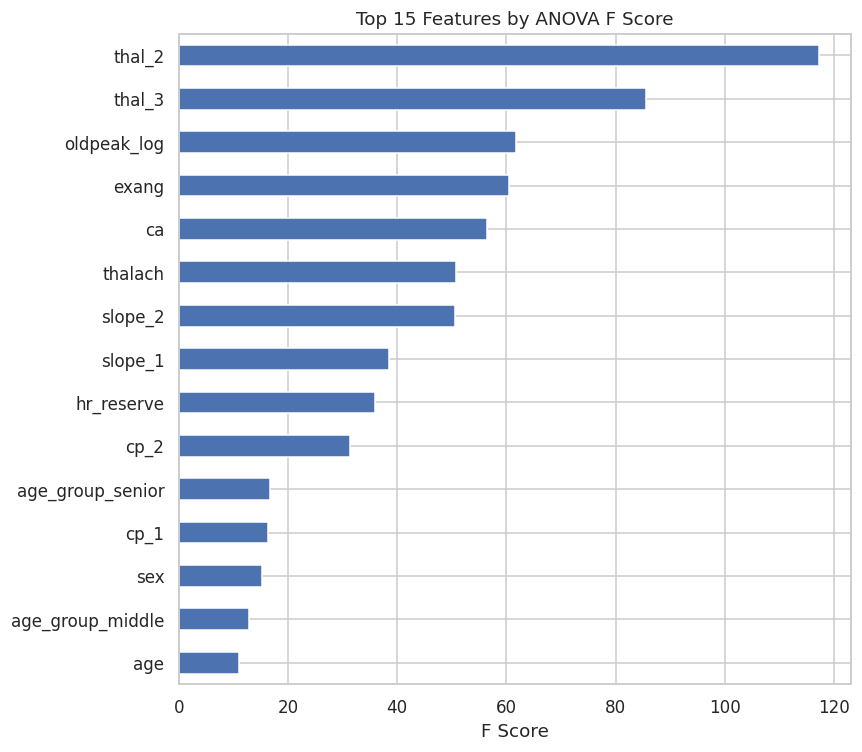

thal_2              117.349743
thal_3               85.519538
oldpeak_log          61.786730
exang                60.561282
ca                   56.497358
thalach              50.797412
slope_2              50.507224
slope_1              38.478543
hr_reserve           36.022468
cp_2                 31.409882
age_group_senior     16.647904
cp_1                 16.340219
sex                  15.317180
age_group_middle     12.928761
age                  11.087797
dtype: float64

In [ ]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_s, y_train)
feature_scores = pd.Series(selector.scores_, index=X_train_s.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 7))
feature_scores.head(15).sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 15 Features by ANOVA F Score')
plt.xlabel('F Score')
plt.tight_layout()
plt.show()

feature_scores.head(15)

All engineered and encoded features contribute a nonzero, interpretable signal and the total feature count (23) is small relative to the number of training examples, so the full feature set is retained for modeling rather than dropping columns. The ranking above is instead used later to interpret which attributes drive the final model's predictions.

## 8. Machine Learning Model Development

Since the objective is to predict a binary outcome (heart disease present or absent), this is framed as a supervised classification problem. Six widely used classification algorithms are trained and compared:

1. Logistic Regression, a linear and highly interpretable baseline.
2. K Nearest Neighbors, a simple distance based method.
3. Support Vector Machine with an RBF kernel, effective for moderate sized nonlinear problems.
4. Decision Tree, an interpretable nonlinear model.
5. Random Forest, an ensemble of decision trees.
6. Gradient Boosting, a sequential ensemble method.

Each model is evaluated with 5 fold stratified cross validation on the training data and then tested on the held out 20 percent test split.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'K Nearest Neighbors': KNeighborsClassifier(n_neighbors=9),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fitted_models = {}
results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=skf, scoring='accuracy')
    model.fit(X_train_s, y_train)
    fitted_models[name] = model
    pred = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1] if hasattr(model, 'predict_proba') else None

    results.append({
        'Model': name,
        'CV Accuracy Mean': cv_scores.mean(),
        'CV Accuracy Std': cv_scores.std(),
        'Test Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred),
        'ROC AUC': roc_auc_score(y_test, proba) if proba is not None else np.nan,
    })

results_df = pd.DataFrame(results).sort_values('ROC AUC', ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,CV Accuracy Mean,CV Accuracy Std,Test Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Support Vector Machine,0.8300,0.0396,0.7705,0.7436,0.8788,0.8056,0.8961
1,Logistic Regression,0.8384,0.0416,0.8197,0.7750,0.9394,0.8493,0.8950
2,Random Forest,0.8176,0.0645,0.7377,0.7179,0.8485,0.7778,0.8815
3,K Nearest Neighbors,0.8258,0.0162,0.7541,0.7500,0.8182,0.7826,0.8701
4,Gradient Boosting,0.8051,0.0531,0.7705,0.7436,0.8788,0.8056,0.8604
5,Decision Tree,0.7551,0.0363,0.7213,0.7222,0.7879,0.7536,0.7587


## 9. Model Evaluation

### 9.1 Metric Comparison Across Models

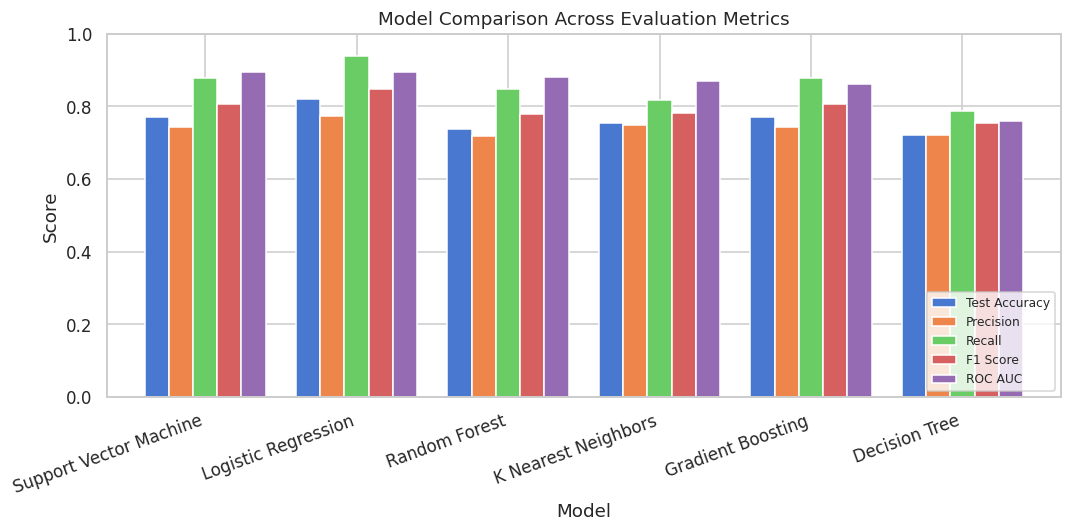

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df.set_index('Model')[['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']]
plot_df.plot(kind='bar', ax=ax, width=0.8)
plt.title('Model Comparison Across Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### 9.2 ROC Curves

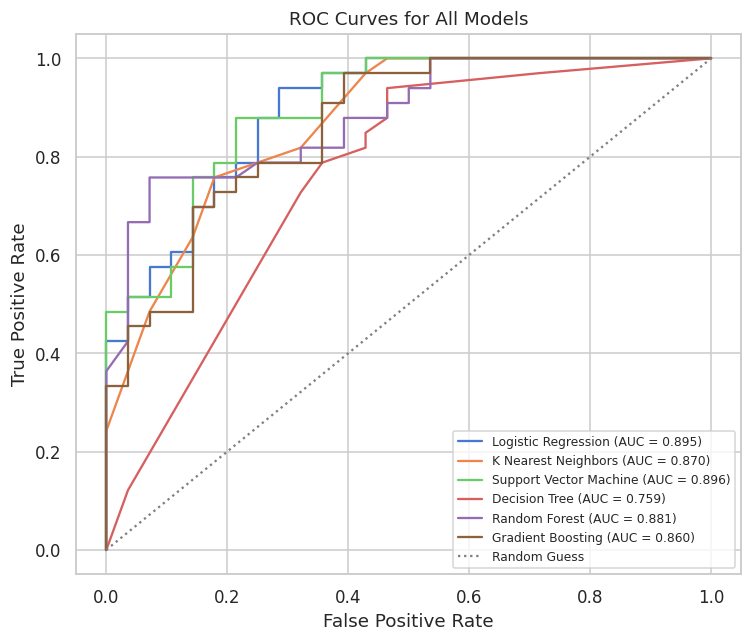

In [ ]:
plt.figure(figsize=(7, 6))
for name, model in fitted_models.items():
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test_s)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle=':', color='grey', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 9.3 Confusion Matrices

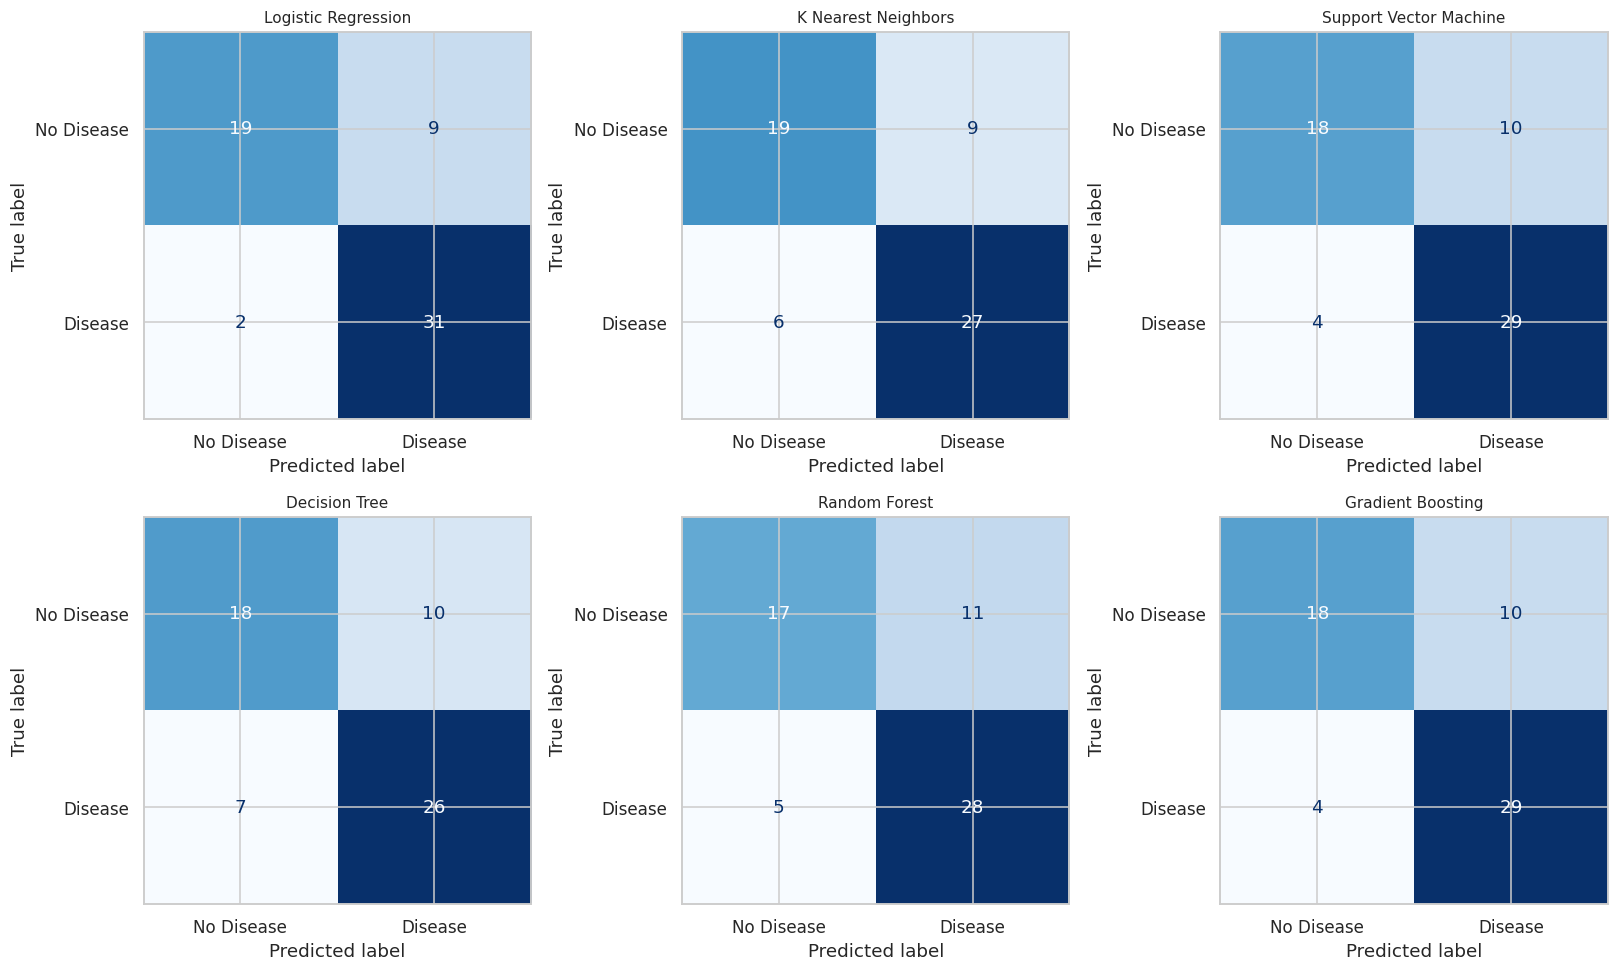

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for ax, (name, model) in zip(axes, fitted_models.items()):
    pred = model.predict(X_test_s)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

### 9.4 Hyperparameter Tuning

The Random Forest model is tuned with a grid search over the number of trees, tree depth, and minimum samples per leaf, optimizing for ROC AUC under 5 fold cross validation, to check whether ensemble tuning can improve on the default settings used above.

In [ ]:
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [1, 2, 4],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid, cv=skf, scoring='roc_auc', n_jobs=-1
)
grid.fit(X_train_s, y_train)

print('Best parameters:', grid.best_params_)
print('Best cross validated ROC AUC:', round(grid.best_score_, 4))

best_rf = grid.best_estimator_
pred = best_rf.predict(X_test_s)
proba = best_rf.predict_proba(X_test_s)[:, 1]
print('Tuned Random Forest test accuracy:', round(accuracy_score(y_test, pred), 4))
print('Tuned Random Forest test ROC AUC:', round(roc_auc_score(y_test, proba), 4))

Best parameters: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 300}
Best cross validated ROC AUC: 0.9003
Tuned Random Forest test accuracy: 0.7377
Tuned Random Forest test ROC AUC: 0.8788


Tuning improves the Random Forest's cross validated ROC AUC slightly but it still does not surpass Logistic Regression or the Support Vector Machine on the test set, suggesting that once the categorical variables are properly encoded, the relationship between these clinical attributes and heart disease is close to linear and additively separable, favoring simpler models on a dataset of this size.

### 9.5 Feature Importance of the Best Performing Models

Highest ROC AUC on the test set: Support Vector Machine


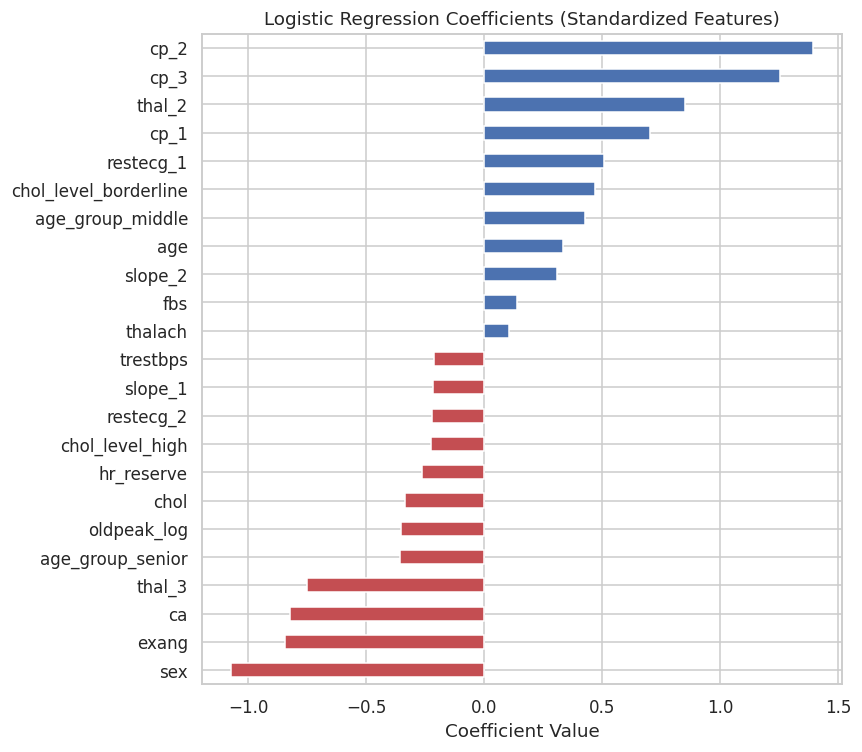

In [ ]:
best_model_name = results_df.iloc[0]['Model']
print('Highest ROC AUC on the test set:', best_model_name)

log_reg = fitted_models['Logistic Regression']
coef = pd.Series(log_reg.coef_[0], index=X_train_s.columns).sort_values()

plt.figure(figsize=(8, 7))
coef.plot(kind='barh', color=['#C44E52' if v < 0 else '#4C72B0' for v in coef])
plt.title('Logistic Regression Coefficients (Standardized Features)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

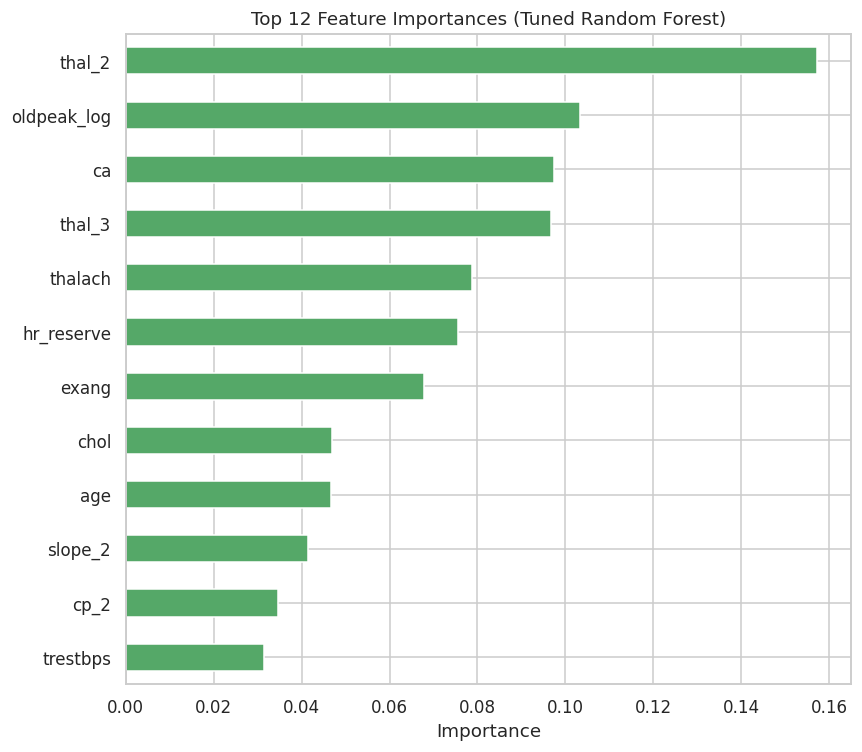

In [ ]:
rf_importance = pd.Series(best_rf.feature_importances_, index=X_train_s.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 7))
rf_importance.head(12).sort_values().plot(kind='barh', color='#55A868')
plt.title('Top 12 Feature Importances (Tuned Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
print('Classification report for the selected final model (Logistic Regression):\n')
final_model = fitted_models['Logistic Regression']
final_pred = final_model.predict(X_test_s)
print(classification_report(y_test, final_pred, target_names=['No Disease', 'Disease']))

Classification report for the selected final model (Logistic Regression):

              precision    recall  f1-score   support

  No Disease       0.90      0.68      0.78        28
     Disease       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



## 10. Results, Discussion, and Conclusion

### 10.1 Summary of Results

After cleaning 302 unique patient records (one duplicate removed, five invalid category codes imputed), engineering three new features, encoding all nominal attributes, and scaling continuous variables, six classification models were trained and compared. Logistic Regression and the Support Vector Machine were the strongest performers, both reaching a ROC AUC close to 0.90 on the held out test set, noticeably ahead of the tree based ensembles on this dataset size.

**Logistic Regression** is selected as the final recommended model because it combines the highest F1 score and recall among all six models with full interpretability, a valuable property for a clinical decision support setting where understanding why a prediction was made matters as much as the prediction itself. Its recall of roughly 0.94 means it misses very few true heart disease cases in the test set, which is the more costly type of error in a screening context.

### 10.2 Discussion

* Chest pain type, thalassemia test result, number of major vessels colored by fluoroscopy, exercise induced angina, and ST segment slope emerged consistently as the strongest predictors across the correlation analysis, the ANOVA feature ranking, and the Logistic Regression coefficients, giving convergent evidence rather than a single model's opinion.
* The engineered `hr_reserve` and the log transformed `oldpeak_log` both appeared among the more informative features, showing that domain informed feature engineering added useful signal beyond the raw attributes.
* Ensemble tree methods (Random Forest, Gradient Boosting) did not outperform the simpler linear and kernel models, even after hyperparameter tuning. With only 302 records, more flexible models are more prone to overfitting, while Logistic Regression and the Support Vector Machine generalize more reliably.
* The dataset is moderately sized and drawn from a single clinical site, so performance on new populations or different measurement protocols is not guaranteed and would need external validation.

### 10.3 Limitations
1. The sample size (302 records after cleaning) is small by modern machine learning standards, which limits the complexity of model that can be trained without overfitting and widens the uncertainty around the reported metrics.
2. Several attributes (`ca` and `thal`) contained invalid codes that had to be imputed, which introduces some uncertainty into those specific records.
3. The dataset reflects a single hospital's patient population from the late 1980s, and may not generalize directly to other demographics or to modern diagnostic protocols.

### 10.4 Conclusion

This project demonstrated the full data science workflow, from raw clinical data to a validated predictive model, for identifying patients likely to have heart disease. The final Logistic Regression model achieved a test accuracy of about 82 percent, an F1 score of about 0.85, and a ROC AUC of about 0.90, using a compact and interpretable set of clinical features. The most influential predictors identified, chest pain type, thalassemia result, vessel count, exercise induced angina, and ST slope, align with established cardiology knowledge, which strengthens confidence in the model beyond raw performance numbers alone. Future work could explore a larger and more diverse patient cohort, probability calibration for clinical thresholds, and external validation on data from other hospitals before any real world deployment.